In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random

import sys
sys.path.append('/ssd/users/Wergillius/Project/TIGON')
import utility 
from importlib import reload

from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
import scanpy as sc

# load data

In [3]:
mk_ery_ad = sc.read_h5ad("/ssd/users/Wergillius/Project/PINN_dynamics/data/ery_mk.h5ad")

In [4]:
mk_ery_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [5]:
timepoints = np.sort(mk_ery_ad.obs['timepoint_tx_days'].unique()) 

In [6]:
timepoints

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [7]:
mk_ery_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

# construct Diffusion map coordis

In [8]:
# slice Diffusion map cooordes by timepoint
DM_ay = []
cbs = []

for t in timepoints:

    cb = mk_ery_ad.obs.query('`timepoint_tx_days` == @t').index
    
    DM_ay.append(mk_ery_ad[cb].obsm['DM_EigenVectors'])
    cbs.append(cb) # the cb is used to reindex the adata

DM_ay = np.array(DM_ay, dtype="object")
cbs = np.concatenate(cbs)

In [24]:
# reindex the adata, sorted by timepoints
mk_ery_ad = mk_ery_ad[cbs].copy()
mk_ery_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [26]:
print(DM_ay.shape)
for dm in DM_ay:
    print(dm.shape)

(9,)
(183, 10)
(400, 10)
(354, 10)
(1732, 10)
(1652, 10)
(2724, 10)
(5295, 10)
(3280, 10)
(7120, 10)


In [72]:
np.save("/ssd/users/Wergillius/Project/PINN_dynamics/data/mkery_DM10.npy", DM_ay, allow_pickle=True)

# TIGON density

In [14]:
sigma = 0.5

In [15]:
# to Tensor
data_train=[]
for i in range(DM_ay.shape[0]):
    data_train.append(torch.from_numpy(DM_ay[i]).type(torch.float32).to('cuda:3'))

In [18]:
time_pts = range(len(data_train))
leave_1_out = []
train_time = [x for i,x in enumerate(time_pts) if i!=leave_1_out]

In [19]:
TIGON_u = []


for i, dm in enumerate(DM_ay):
    dm_ts = torch.from_numpy(dm).type(torch.float32).to('cuda:3')
    with torch.no_grad():
        u = utility.MultimodalGaussian_density(dm_ts, train_time, i , data_train, sigma, device='cuda:3')
    TIGON_u.append(u.detach().cpu().numpy())

TIGON_u = np.concatenate(TIGON_u, axis=0)

In [28]:
mk_ery_ad.obs['TIGON_u_DM10'] = TIGON_u

# Plot TIGON u

In [47]:
from importlib import reload
import plotting_fn as pl_fn

reload(pl_fn)

<module 'plotting_fn' from '/ssd/users/Wergillius/Project/PINN_dynamics/Explore_Notebook/density/plotting_fn.py'>

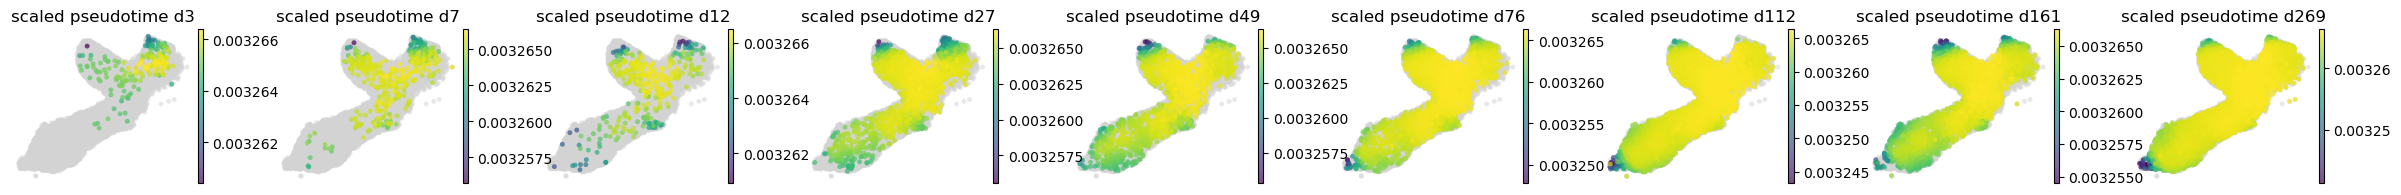

In [64]:
fig, axs = pl_fn.umap_by_time('TIGON_u_DM10', mk_ery_ad)

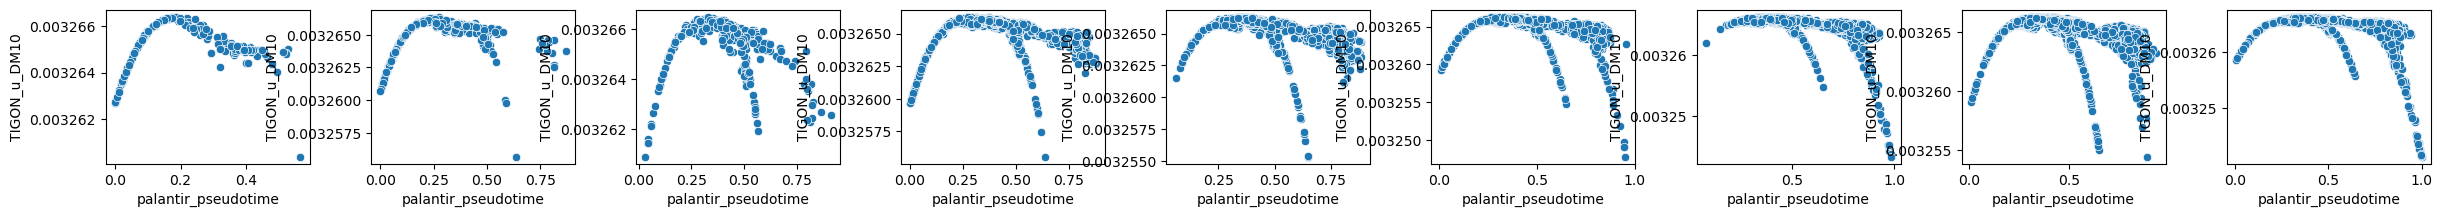

In [65]:
pl_fn.scatter_density('TIGON_u_DM10', mk_ery_ad, 'palantir_pseudotime');

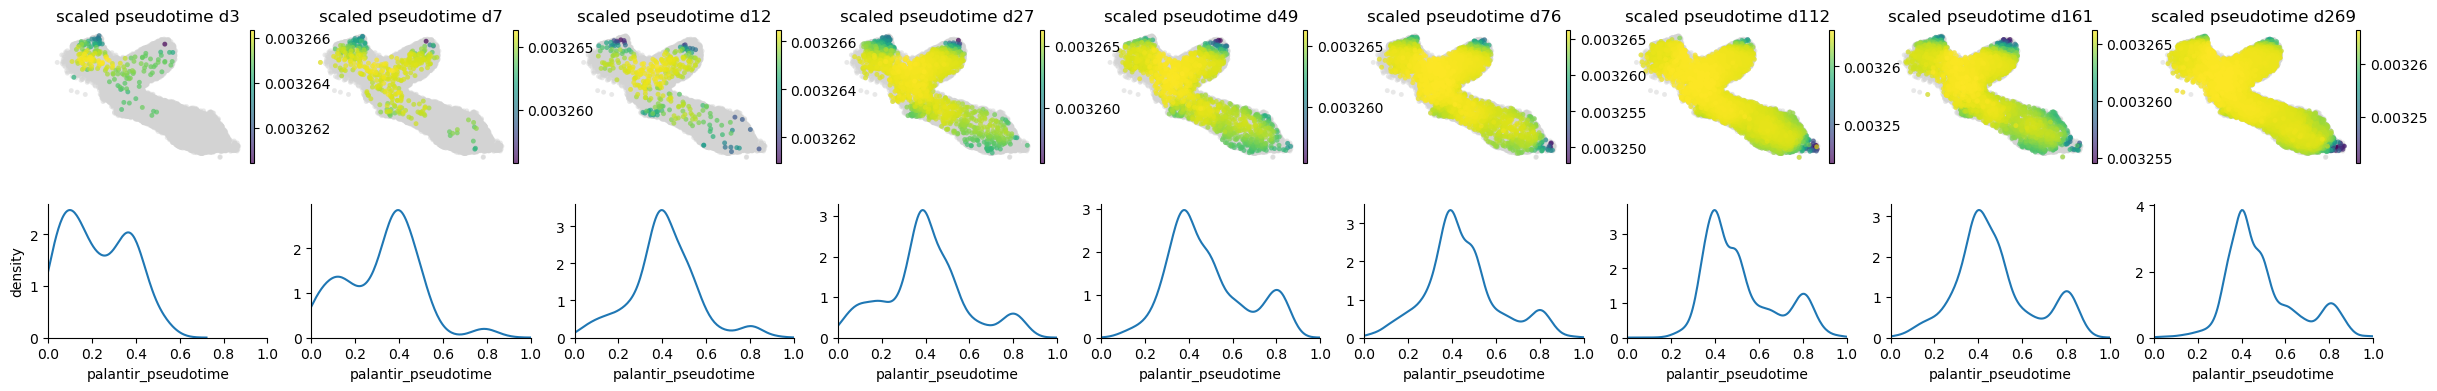

In [66]:
figg2 = pl_fn.plot_along_pseudotime('TIGON_u_DM10',mk_ery_ad, 'palantir_pseudotime')

# guassian kde fn

In [49]:
from scipy.stats import gaussian_kde,entropy

In [83]:
def compute_guassian_u(Cellstate_ay, dimension=10):
    r"""
    Estimating the density high dimensional cell state coordinates and its change by experimental time.
    The density estimation function is 
    
    Input
    -------
    Cellstate_ay : ndarray of shape (N_cell, dimension), the high dimensional cell state representation, i.e. PC, Diffusion Map (DM) , SCVI-latent
    dimension : control the nubmer of the first few dimension to use for density esitmation

    Return
    -------
    gussian_kde_u : ndarray of shape (N_cell, 1), the density of each cell 

    Example
    ------
    >>> timepoints = sorted(ad.obs.timepoint_tx_days.unique()) # get timepoints
    >>> cbs_t = [ad.obs.query("`timepoint_tx_days` == @t").index for t in timepoints]
    >>> DM_ay = [ad[cb].obsm['DM_eigen'] for cb in cbs_t]
    >>> gussian_kde_u = guassian_u(DM_ay, dimension=5)
    >>> ad.obs['DM5_gaussisn_u']= gussian_kde_u

    """
    gussian_kde_u = []

    for dm in Cellstate_ay:
        # print(pc.shape)
        kde_fn = gaussian_kde(dm.T, bw_method='silverman')       # take in [n_dim, n_sample]
        gussian_kde_u.append(kde_fn(dm.T))

    gussian_kde_u = np.concatenate(gussian_kde_u, axis=0)

    return gussian_kde_u

In [51]:
mk_ery_ad.obs['gaussian_kde_u'] = compute_guassian_u(DM_ay, 10)

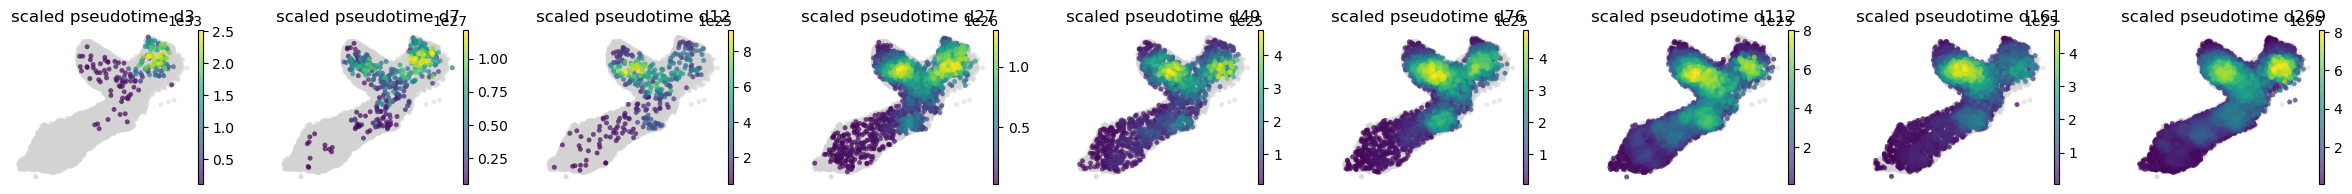

In [54]:
fig, axs = pl_fn.umap_by_time('gaussian_kde_u',mk_ery_ad);

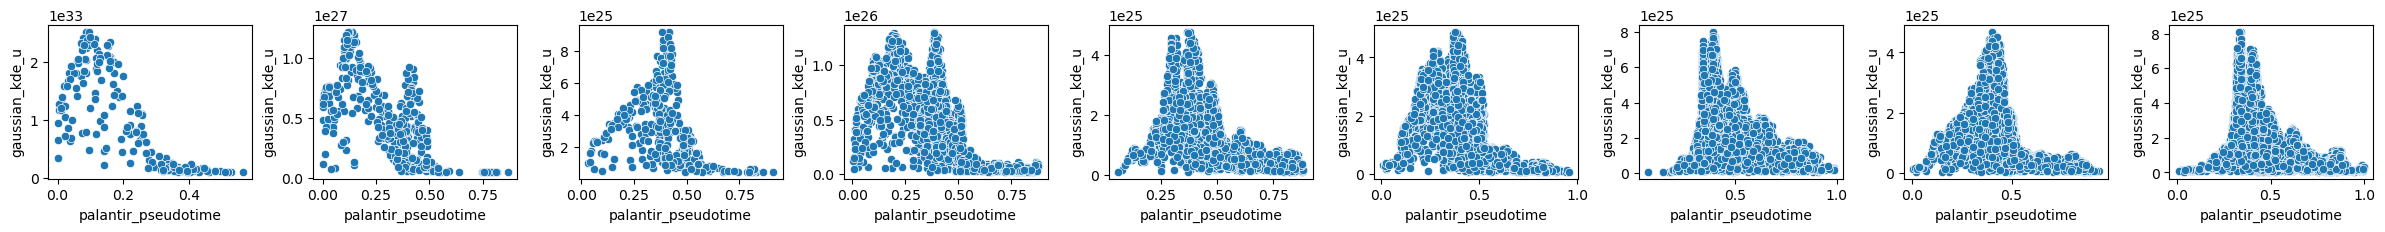

In [58]:
pl_fn.scatter_density('gaussian_kde_u', mk_ery_ad, pt_col='palantir_pseudotime');

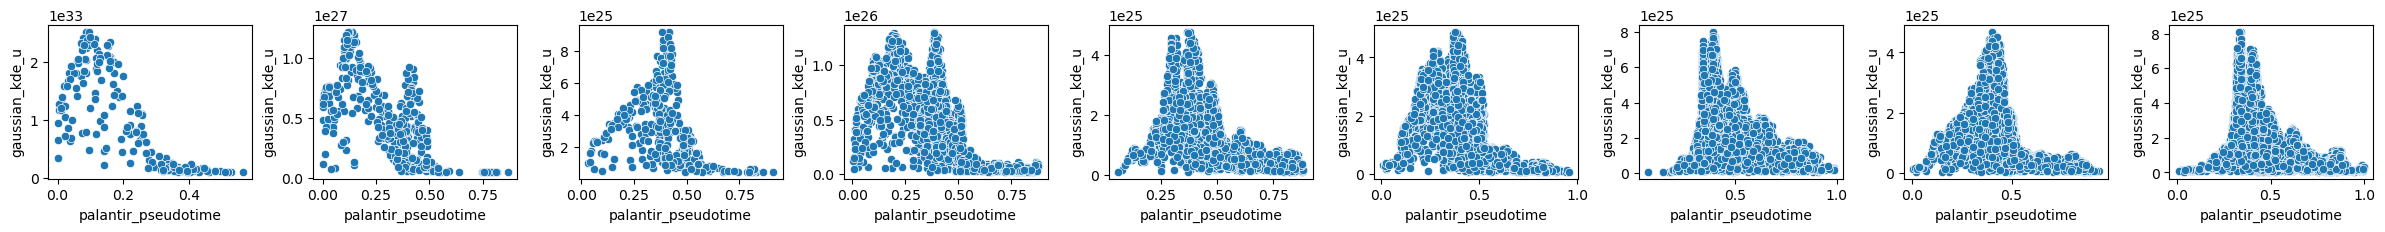

In [ ]:
pl_fn.plot_along_pseudotime('gaussian_kde_u', mk_ery_ad, pt_col='palantir_pseudotime');

In [60]:
mk_ery_ad.obs['gaussian_kde_u_dm5'] = compute_guassian_u(DM_ay, 5)


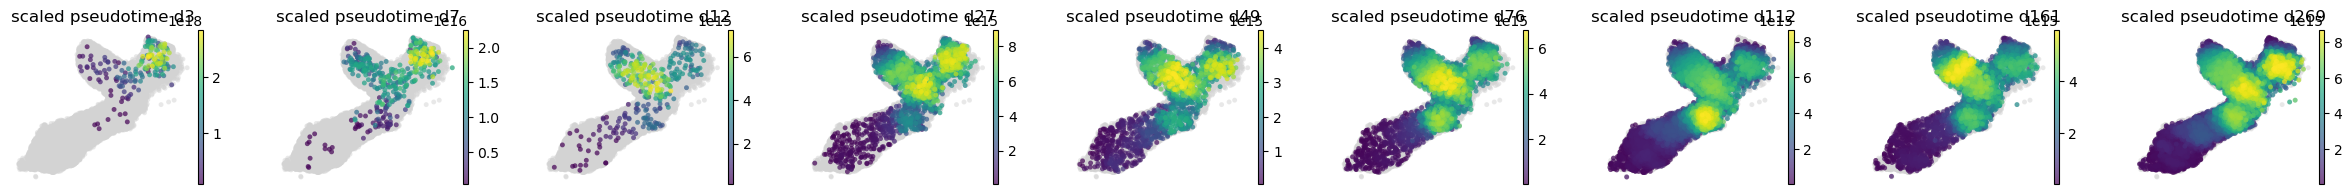

In [61]:
fig, axs = pl_fn.umap_by_time('gaussian_kde_u_dm5', mk_ery_ad);

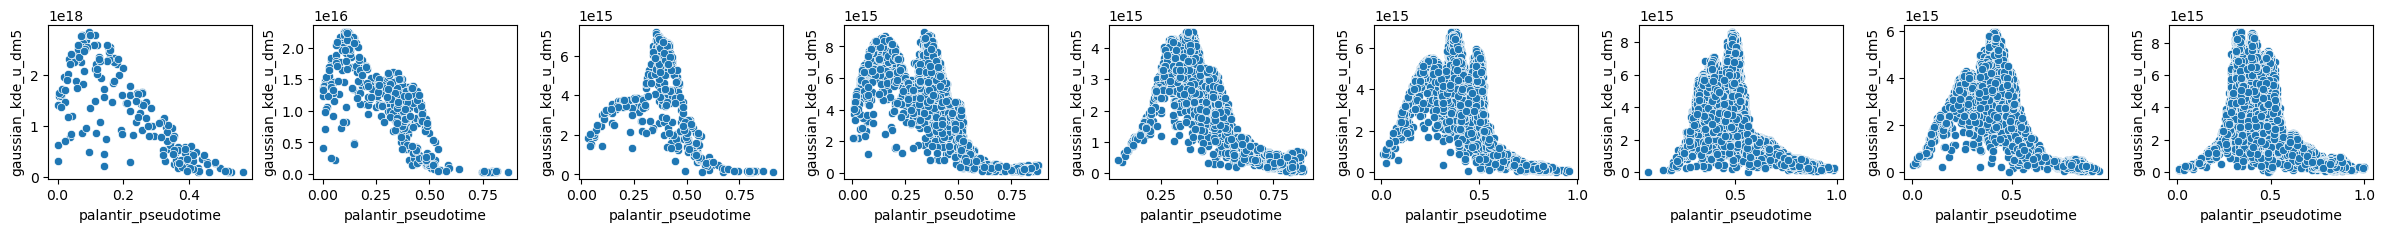

In [63]:
pl_fn.scatter_density('gaussian_kde_u_dm5',mk_ery_ad, 'palantir_pseudotime');

# Denmarf KDE

In [69]:
from denmarf import DensityEstimate

In [70]:
save_dir = "/ssd/users/Wergillius/Project/PINN_dynamics/Explore_Notebook/density"

In [73]:
de = DensityEstimate()

In [ ]:
de.fit()

In [71]:
de = DensityEstimate.from_file(filename="filename_for_the_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'filename_for_the_model.pkl'

In [128]:
denmarf_u = []

for i, dm in enumerate(DM_ay):
    
    de = DensityEstimate.from_file(filename=f"{save_dir}/DiffMap10_day{timepoints[i]}th.pkl")
    u = np.exp(de.score_samples(dm[:,:10]))
    denmarf_u.append(u)


u_ay = np.concatenate(denmarf_u, axis=0)

mk_ery_ad.obs['denmarf_u_DM10'] =  np.clip(
        u_ay, *np.quantile(u_ay, [0.05, 1])
    )

In [124]:
denmarf_u = []

for i, dm in enumerate(DM_ay):
    
    de = DensityEstimate.from_file(filename=f"{save_dir}/DiffMap30_day{timepoints[i]}th.pkl")
    u = np.exp(de.score_samples(dm))
    denmarf_u.append(u)

u_ay = np.concatenate(denmarf_u, axis=0)

mk_ery_ad.obs['denmarf_u_DM30'] =  np.clip(
        u_ay, *np.quantile(u_ay, [0.05, 1])
    )

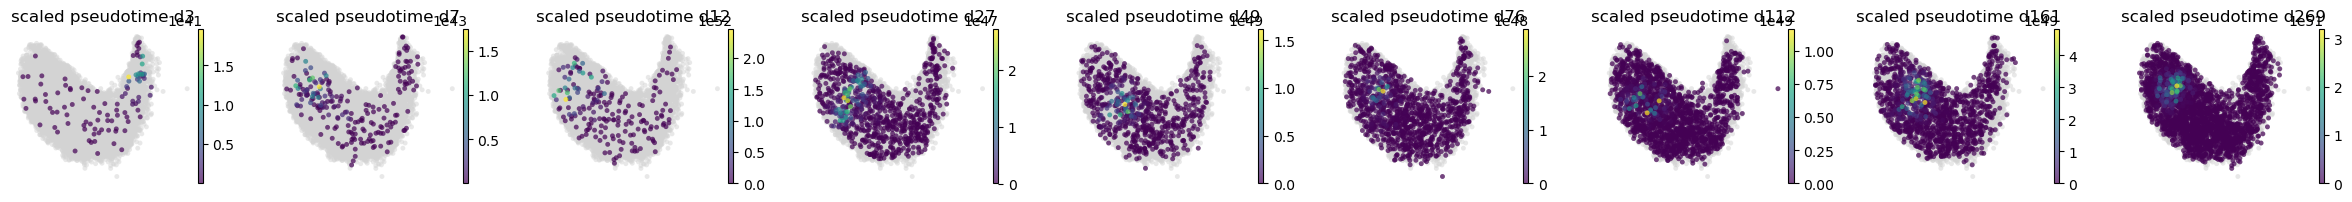

In [129]:
fig, axs = umap_by_time('denmarf_u_DM10')
fig

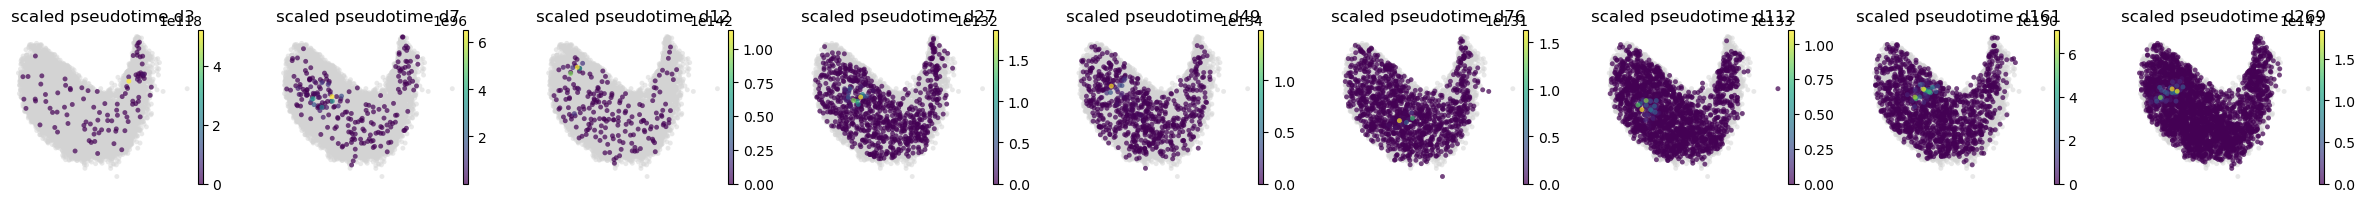

In [130]:
fig, axs = umap_by_time('denmarf_u_DM30')
fig

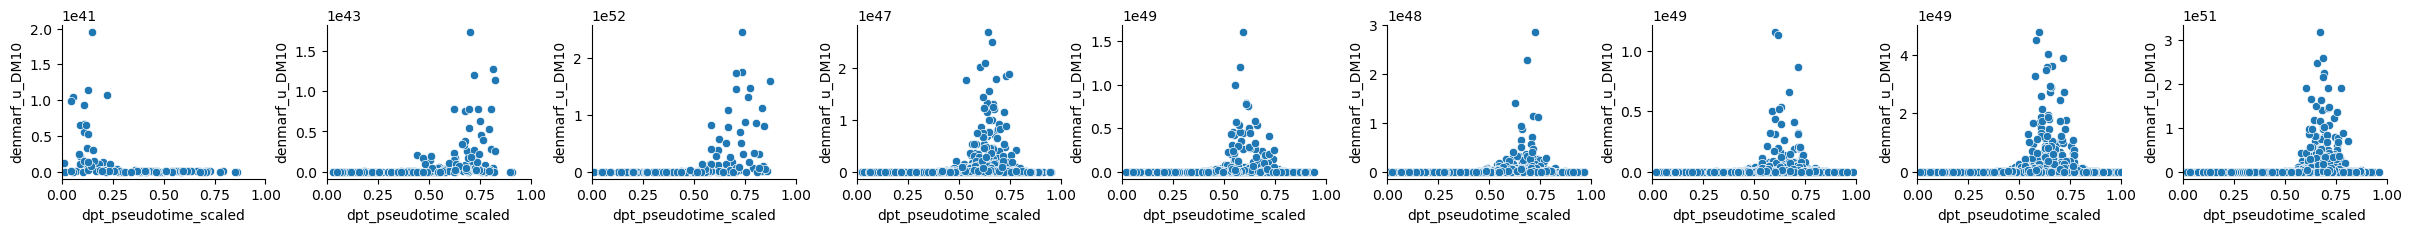

In [180]:
scatter_density('denmarf_u_DM10')

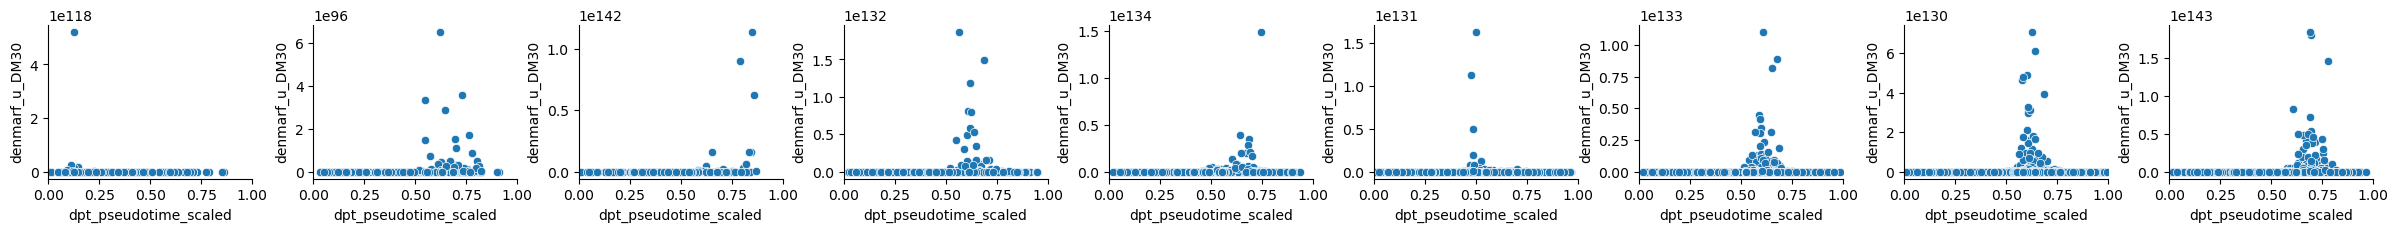

In [181]:
scatter_density('denmarf_u_DM30')

# save all to h5ad

In [74]:
mk_ery_ad.write_h5ad("/ssd/users/Wergillius/Project/PINN_dynamics/data/mk_ery_DM_densityEst.h5ad")